# TP - Communications numériques multi-porteuses (OFDM)
## TP 2 - reprise intégrale du TP 1, puis préfixe cyclique et performance
*Module ORPHeO | ComRF - Comm. Num. (Multiporteuses) - ENIB - P. Morel*

Ce document (`TP2_<prenom-nom>.ipnyb`) est à remettre par mail idéalement en fin de séance (au plus tard le 15/09/2026 minuit) **morel@enib.fr**

**Séance en autonomie (non encadrée).** Ce notebook est **auto-porteur** : il reprend
l'intégralité du TP 1 (postes 0 à 5), puis résout la question laissée ouverte au poste 5,
avec les postes 6 à 8.

**Objectif.** Construire une chaine OFDM complète sur le canal *personnel* attribué,
comprendre
**pourquoi** un égaliseur exact ne suffit pas, et **ce que le préfixe cyclique répare**.

### Objectifs d'apprentissage - à l'issue de la séance, l'étudiant sait :
1. Tout ce qui est visé au TP 1 (postes 0 à 5).
2. **Prédire** la longueur minimale du préfixe cyclique à partir de l'étalement des retards,
   et la **vérifier** par la mesure.
3. **Expliquer** pourquoi on recopie la queue du symbole plutôt que d'insérer des zéros
   (convolution circulaire).
4. **Tracer** la courbe de BER de la chaine et **expliquer** son écart à la référence AWGN.
5. **Localiser** les erreurs dans la bande et les **relier** aux creux de |H[k]|.

### Mode de travail
- **Postes 0 à 5 : tout le code est FOURNI.** Ces postes ont été construits en séance
  encadrée ; il n'y a rien à réécrire ici. Les exécuter dans l'ordre, **regarder les
  figures**, et s'arrêter sur celle du poste 5 : c'est elle qui pose la question de la
  séance. Cette reprise doit aller vite : rien n'y est à réécrire.
- Les cellules **CR 1 à CR 4** ne sont à remplir que si elles ne l'ont pas été au TP 1.
- **Les postes 6, 7 et 8 sont le travail de cette séance.** Une seule fonction est à
  écrire - `ajoute_cp`, au poste 6 : c'est la notion même de la séance. Le reste du travail
  est de **prédire, mesurer et interpréter** ; c'est là que se joue le compte-rendu.
- Blocage : chaque point difficile est accompagné d'une démonstration guidée. Ces
  démonstrations remplacent l'enseignant : les lire attentivement.
- **Terminé en avance ?** Le **Défi** en fin de notebook est fait pour cela : il n'a pas de
  plafond. L'**extension E0** permet par ailleurs de réécrire soi-même les fonctions du TP 1.

> **ORDRE DE PRIORITÉ.** Postes 6 et 7 en premier. Le poste 8 est bref, mais c'est lui qui
> fait le lien avec le cours (ADSL contre TNT) : ne pas le sauter. Les Extensions restent
> optionnelles.

### 0 - Mise en route
Renseigner l'**identifiant**, puis exécuter. La cellule fabrique le canal multitrajet
**attribué à cet identifiant** (4 à 6 trajets, profil de puissance décroissant) et affiche
sa réponse impulsionnelle. Deux étudiants n'ont pas le même canal : les résultats
numériques obtenus ici sont propres à chacun.

In [1]:
import numpy as np, hashlib
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft
from math import erfc
_erfc = np.vectorize(erfc)
def Q(x): return 0.5*_erfc(np.asarray(x, float)/np.sqrt(2))   # proba d'erreur AWGN (théorie)

IDENTIFIANT = "antoine.turpin"          # <-- À RENSEIGNER : fabrique un canal UNIQUE
ETIQUETTE   = "sem1 2026-2027"      # fixé par l'enseignant
N = 64                              # nombre de sous-porteuses
NBITS = 2                           # bits par symbole : 2 = QPSK (le TP se fait en QPSK).
                                    # 1 = BPSK, 4 = 16-QAM, 6 = 64-QAM : TOUTE la chaine suit.

if IDENTIFIANT.strip().lower() in ("", "prenom.nom"):
    raise ValueError("IDENTIFIANT doit être renseigné (forme prenom.nom) avant de continuer : "
                     "à défaut, le canal utilisé serait le canal de démonstration, "
                     "commun à toute la promotion.")

def _canal(sid, e):
    """Canal multitrajet dérivé de l'identifiant : 4 à 6 trajets résolus, profil de
    puissance décroissant exponentiellement (PDP), phases aléatoires. Le dernier
    trajet fixe l'étalement des retards tau (= la mémoire du canal)."""
    d = hashlib.sha256(f"{sid}|{e}".encode()).digest()
    r = np.random.default_rng(int.from_bytes(d[:8], "big"))
    for _ in range(200):                                        # tirage sous contraintes
        L   = int(r.choice([9, 11, 13, 15]))                    # étalement des retards
        npa = int(r.integers(4, 7))                             # nombre de trajets
        mid = r.choice(np.arange(1, L), size=npa-2, replace=False)
        dly = np.sort(np.concatenate([[0], mid, [L]])).astype(int)
        pdp = np.exp(-dly/(L/2.5)) * r.uniform(.7, 1.3, dly.size)
        ph  = r.uniform(0, 2*np.pi, dly.size); ph[0] = 0        # trajet direct = référence de phase
        h = np.zeros(L+1, complex); h[dly] = np.sqrt(pdp)*np.exp(1j*ph)
        h /= np.sqrt((np.abs(h)**2).sum())
        H = fft(h, N)
        if (abs(h[L])**2 >= 0.05*abs(h[0])**2 and
            0.10 <= np.abs(H).min() <= 0.55 and np.abs(H).max() <= 1.9):
            return h
    raise RuntimeError("tirage de canal impossible")

h_moi = _canal(IDENTIFIANT, ETIQUETTE); H_moi = fft(h_moi, N)
tau = len(h_moi)-1
print(f"Canal attribué : {int((np.abs(h_moi)>1e-12).sum())} trajets ; "
      f"étalement des retards tau = {tau} échantillons ; "
      f"|H|min = {np.abs(H_moi).min():.3f} ; |H|max = {np.abs(H_moi).max():.3f}")

Canal attribué : 5 trajets ; étalement des retards tau = 13 échantillons ; |H|min = 0.147 ; |H|max = 1.741


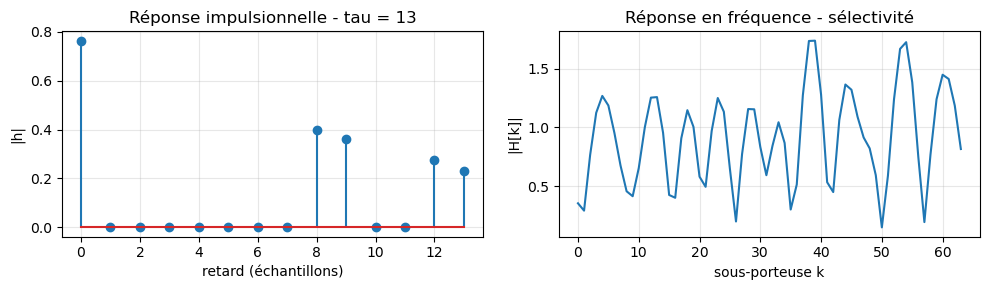

A gauche : le trajet direct (retard 0) et ses répliques. Le DERNIER trajet significatif
           est à l'indice 13 : c'est l'étalement des retards tau (cours).
A droite : |H[k]| n'est PAS plat -> canal SÉLECTIF en fréquence. Les creux coûteront cher.


In [2]:
# Le canal attribué, dans les deux domaines : réponse impulsionnelle et réponse en fréquence.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.0))
ax[0].stem(np.arange(len(h_moi)), np.abs(h_moi))
ax[0].set_xlabel("retard (échantillons)"); ax[0].set_ylabel("|h|")
ax[0].set_title(f"Réponse impulsionnelle - tau = {tau}"); ax[0].grid(alpha=.3)
ax[1].plot(np.abs(H_moi)); ax[1].set_xlabel("sous-porteuse k"); ax[1].set_ylabel("|H[k]|")
ax[1].set_title("Réponse en fréquence - sélectivité"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"A gauche : le trajet direct (retard 0) et ses répliques. Le DERNIER trajet significatif")
print(f"           est à l'indice {tau} : c'est l'étalement des retards tau (cours).")
print(f"A droite : |H[k]| n'est PAS plat -> canal SÉLECTIF en fréquence. Les creux coûteront cher.")

## 1 - Le mapping : des bits aux symboles
Avant toute modulation, il faut un **alphabet** : associer des groupes de bits à des points
(=> nombre de bits/symbole) du plan I/Q (la *constellation*). En **QPSK**, 2 bits -> 1 point parmi 4.

Le mapping est un **prérequis** du module, pas l'objet de ce TP : le code est **fourni**.
Le lire, l'exécuter, et vérifier que la constellation obtenue est celle attendue.

Il est écrit pour **une taille quelconque de constellation** : le paramètre `NBITS` de la
mise en route fixe le nombre de bits par symbole (2 = QPSK, et c'est le réglage du TP), et
**toute la chaîne s'y conforme** — mapping, décision, bruit, courbes de référence. L'extension
E1 s'en sert pour rejouer la séance en 16-QAM et en 64-QAM sans rien réécrire.

La figure suit **le premier maillon de la chaîne** : un flux de bits, groupés par `NBITS`,
chaque groupe devenant un point de la constellation. La couleur d'un symbole — son quadrant —
sera conservée dans toutes les figures suivantes.

In [3]:
# MAPPING - fourni, et valable pour TOUTE taille de constellation (NBITS bits/symbole).
# Le mot de NBITS bits est coupe en deux : la 1re moitie donne l'amplitude sur I, la
# seconde sur Q. Dans chaque moitie, le 1er bit porte le SIGNE et les suivants la
# magnitude en code de Gray - deux points voisins ne different alors que d'un bit.
# L'energie moyenne du symbole vaut 1 quel que soit NBITS.
def _pam(demi):                 # demi-mot (..., k) -> amplitude entiere impaire
    k = demi.shape[-1]
    g = np.zeros(demi.shape[:-1], dtype=int); c = np.zeros_like(g)
    for i in range(1, k):
        c = c ^ demi[...,i]; g = g*2 + c                        # decodage de Gray
    return (1 - 2*demi[...,0])*(2*g + 1)

def _pam_inv(a, k):             # amplitude -> k bits (decision au niveau le plus proche)
    g  = np.clip(((np.abs(a) - 1)/2).round().astype(int), 0, 2**(k-1) - 1)
    gr = g ^ (g >> 1)
    return np.stack([(a < 0).astype(int)] + [(gr >> (k-1-i)) & 1 for i in range(1,k)], -1)

def _echelle(m):                # normalisation : energie moyenne du symbole = 1
    return 1.0 if m == 1 else np.sqrt(2*np.mean((2*np.arange(2**(m//2-1)) + 1)**2))

def qam_mod(bits, m=None):      # bits (..., m) -> symboles complexes
    m = NBITS if m is None else m
    bits = np.asarray(bits)
    if m == 1: return (1 - 2*bits[...,0]).astype(complex)
    k = m//2
    return (_pam(bits[...,:k]) + 1j*_pam(bits[...,k:]))/_echelle(m)

def qam_demod(s, m=None):       # symboles -> bits (decision au plus proche voisin)
    m = NBITS if m is None else m
    s = np.asarray(s)
    if m == 1: return (s.real < 0).astype(int)[...,None]
    k = m//2; e = _echelle(m)
    return np.concatenate([_pam_inv(s.real*e, k), _pam_inv(s.imag*e, k)], -1)

def ber_of(bits, Xh, m=None):
    return np.mean(qam_demod(Xh, m) != bits)

def ber_awgn(eb_db, m=None):    # reference theorique en canal AWGN, mapping de Gray
    m = NBITS if m is None else m
    g = 10**(np.asarray(eb_db, float)/10)
    if m <= 2: return Q(np.sqrt(2*g))
    M = 2**m
    return (4/m)*(1 - 1/np.sqrt(M))*Q(np.sqrt(3*m*g/(M - 1)))

def bits_alea(rng, *forme):     # un bloc de bits a la taille du mapping courant
    return rng.integers(0, 2, tuple(forme) + (NBITS,))

# COULEURS - une QAM carree est un quadtree : chaque PAIRE de bits (un de I, un de Q)
# choisit un quadrant a une echelle deux fois plus fine. C'est ce que le code de Gray
# encode, et la couleur le montre : la TEINTE donne le quadrant (bits de signe), la
# NUANCE donne le sous-quadrant (paire de bits suivante). A NBITS = 2 il n'y a qu'un
# niveau, et la teinte suffit a nommer le symbole.
COUL4 = ["#e60000", "#00b32c", "#ffd400", "#0033cc"]     # (I+,Q+) (I+,Q-) (I-,Q+) (I-,Q-)
NOMS4 = ["00", "01", "10", "11"]
NOM_CONST = {1:"BPSK", 2:"QPSK", 4:"16-QAM", 6:"64-QAM"}.get(NBITS, f"{2**NBITS}-QAM")
NIV_COUL = min(max(NBITS//2, 1), 2)          # niveaux de quadrant que la couleur code

def mots_binaires(m=None):      # les 2^m mots possibles, dans l'ordre
    m = NBITS if m is None else m
    return (np.arange(2**m)[:,None] >> np.arange(m-1,-1,-1)) & 1

def indice_quad(bits, niveau=1):
    """0..3 : le quadrant au niveau demande. Niveau 1 = les bits de signe ;
    niveau 2 = la paire suivante (sous-quadrant) ; etc."""
    b = np.asarray(bits); k = max(NBITS//2, 1)
    bi = b[..., min(niveau-1, k-1)]
    bq = b[..., min(k+niveau-1, NBITS-1)] if NBITS >= 2 else bi
    return (bi*2 + bq).astype(int)

def indice4(bits): return indice_quad(bits, 1)           # le quadrant, tout court

def _nuance(hexa, j, n):        # j-ieme des n nuances d'une teinte (vers le blanc)
    r, g, b = (int(hexa[i:i+2], 16)/255 for i in (1, 3, 5))
    f = 0.0 if n <= 1 else .58*j/(n-1)
    return (r + (1-r)*f, g + (1-g)*f, b + (1-b)*f)

def couleur(bits):
    """La couleur d'un symbole : teinte = quadrant, nuance = sous-quadrant."""
    q1 = indice_quad(bits, 1)
    n2 = 4 if NIV_COUL >= 2 else 1
    q2 = indice_quad(bits, 2) if n2 > 1 else np.zeros_like(q1)
    plat = [_nuance(COUL4[a], b, n2) for a, b in zip(np.ravel(q1), np.ravel(q2))]
    return np.array(plat).reshape(np.shape(q1) + (3,))

def grille_quadrants(_a):
    """Les frontieres de quadrants, de la plus grossiere a la plus fine."""
    _a.axhline(0, color="#8a8a8a", lw=1.5, zorder=0)
    _a.axvline(0, color="#8a8a8a", lw=1.5, zorder=0)
    if NBITS < 4: return
    _k = NBITS//2; _A = 2**_k; _e = _echelle(NBITS)
    for _j in range(2, _k+1):
        _pas = 2**(_k-_j+1)
        _col, _lw = ("#b4b4b4", 1.0) if _j == 2 else ("#d8d8d8", .7)
        for _v in range(-_A+_pas, _A, _pas):
            if _v % (2*_pas):
                _a.axvline(_v/_e, color=_col, lw=_lw, zorder=0)
                _a.axhline(_v/_e, color=_col, lw=_lw, zorder=0)

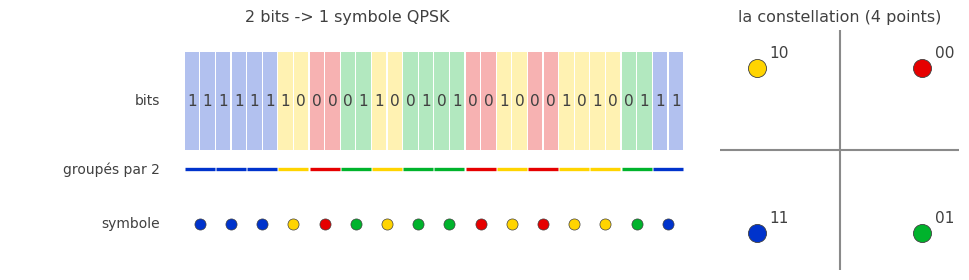

Constellation QPSK : 4 points, 2 bits/symbole ; énergie moyenne = 1.000 (normalisée à 1).


In [4]:
# MAILLON 1 : le flux binaire devient un flux de symboles.
# La figure suit NBITS : elle est tracee pour la constellation reglee a la mise en route.
_nb = max(4, 32//NBITS)                              # nb de symboles montres
_bits = bits_alea(np.random.default_rng(7), _nb); _co = couleur(_bits)
_L = NBITS*_nb                                       # longueur du flux binaire montre
_fig, _ax = plt.subplots(1, 2, figsize=(10, 2.9), gridspec_kw={"width_ratios":[2.4, 1]})
_a = _ax[0]
for _n, _bit in enumerate(_bits.reshape(-1)):
    _a.add_patch(plt.Rectangle((_n, 0), .92, .82, color=_co[_n//NBITS],
                               alpha=.30 if NIV_COUL < 2 else .42, lw=0))
    _a.text(_n+.46, .41, str(_bit), ha="center", va="center", fontsize=11, color="#404040")
for _q in range(_nb):
    _a.plot([NBITS*_q, NBITS*_q+NBITS-.08], [-.16]*2, color=_co[_q], lw=2.4,
            solid_capstyle="butt")
    _a.plot(NBITS*_q+NBITS/2-.04, -.62, "o", color=_co[_q], ms=8, mec="#404040", mew=.5)
for _y, _t in [(.41, "bits"), (-.16, f"groupés par {NBITS}"), (-.62, "symbole")]:
    _a.text(-.05*_L, _y, _t, ha="right", va="center", fontsize=10, color="#404040")
_a.set_xlim(-.35*_L, _L); _a.set_ylim(-1.0, 1.0); _a.axis("off")
_a.set_title(f"{NBITS} bits -> 1 symbole {NOM_CONST}", fontsize=11.5, color="#404040")
_a = _ax[1]
_mots = mots_binaires(); _pts = qam_mod(_mots); _cm = couleur(_mots)
_ms = 13 if NBITS <= 2 else (10 if NBITS == 4 else 5)
grille_quadrants(_a)                     # trait epais = quadrant, fin = sous-quadrant
for _k in range(len(_mots)):
    _a.plot(_pts[_k].real, _pts[_k].imag, "o", color=_cm[_k], ms=_ms,
            mec="#404040", mew=.6)
    if NBITS <= 4:
        _a.annotate("".join(map(str, _mots[_k])), (_pts[_k].real, _pts[_k].imag),
                    textcoords="offset points", xytext=(9,7),
                    fontsize=11 if NBITS <= 2 else 7.5, color="#404040")
_lim = 1.45*np.max(np.abs(_pts.real))
_a.set_xlim(-_lim,_lim); _a.set_ylim(-_lim,_lim); _a.set_box_aspect(1)
_a.set_xticks([]); _a.set_yticks([])
for _sp in _a.spines.values(): _sp.set_visible(False)
_a.set_title(f"la constellation ({2**NBITS} points)" if NBITS <= 2 else
             f"la constellation ({2**NBITS} points) : quadrants et sous-quadrants",
             fontsize=10.5 if NBITS > 2 else 11.5, color="#404040")
plt.tight_layout(); plt.show()
print(f"Constellation {NOM_CONST} : {2**NBITS} points, {NBITS} bits/symbole ; "
      f"énergie moyenne = {np.mean(np.abs(qam_mod(_mots))**2):.3f} (normalisée à 1).")
if NBITS >= 4:
    print("La TEINTE donne le quadrant (les 2 bits de signe), la NUANCE le sous-quadrant")
    print("(les 2 bits suivants) : chaque paire de bits recoupe le plan en quatre. C'est la")
    print("structure meme du code de Gray - deux points voisins ne different que d'un bit.")
    if NBITS > 4:
        print(f"A {2**NBITS} points, le dernier niveau n'est plus code par la couleur : les")
        print("blocs de 2x2 points partagent une nuance, seule la grille les separe.")

**CR 1.** Combien de bits par symbole en QPSK ? Que deviendrait le débit avec 16 points
au lieu de 4, à bande égale (voir Extension E1) ? Et qu'est-ce qui se dégrade en échange ?

In [ ]:
# réponse : on obtient 2 bits/symbole en QPSK -> A bande égale on obtient 4 bits par symbole, ce qui diminu la redondance 

## 2 - Le problème : l'interférence entre symboles (ISI)
Le canal comporte plusieurs trajets. En **mono-porteuse**, chaque symbole occupe M échantillons
consécutifs. Si les symboles sont **courts** devant l'étalement des retards, les répliques d'un
symbole débordent sur le suivant : c'est l'**ISI** (cours, slides 7-8).

La démonstration qui suit compare des symboles **courts** (M = 1), **intermédiaires**
(M = 32) et **longs** (M = 256), sur le canal personnel attribué.

**Prédire d'abord**, ensuite seulement lancer la démonstration. Une prédiction fausse,
conservée et discutée, vaut autant qu'une prédiction juste : c'est l'écart entre les deux
qui fait apprendre.

In [ ]:
# PRÉDICTION - à remplir AVANT d'exécuter les cellules suivantes.
# Que va faire la BER quand les symboles s'allongent (M = 1, puis 32, puis 256) ?
PREDICTION_ISI = "Quand M augmente, La BER va avoir de moins en moins de débordement provoqué par les échos. Donc avec M=1 on aura beaucoup d'échos qui perturbe et avec M=256 on aura un message sans débordement (débit de message diminué) "    # forme attendue : "quand M augmente, la BER ..., parce que ..."

In [5]:
def mono(h, M, eb, ns, rng):   # fourni : chaine MONO-porteuse (chaque symbole dure M échantillons)
    bits = bits_alea(rng, ns); s = qam_mod(bits); tx = np.repeat(s, M)
    y = np.convolve(tx, h)[:len(tx)]; N0 = 1/(10**(eb/10)*NBITS)
    y = y + np.sqrt(N0/2)*(rng.standard_normal(len(y)) + 1j*rng.standard_normal(len(y)))
    yc = y.reshape(ns, M).mean(1); g = np.vdot(s, yc)/np.vdot(s, s); yc = yc/g
    return np.mean(qam_demod(yc) != bits), yc, s, np.mean(np.abs(yc-s)**2)

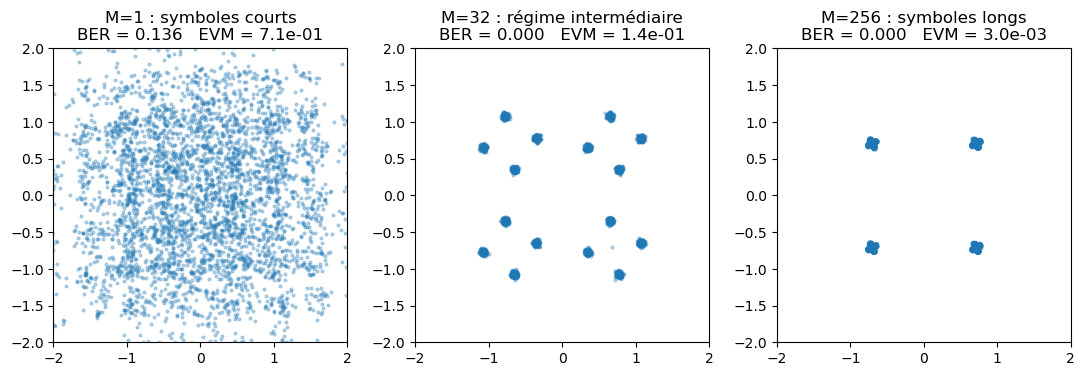

COURT : l'écho déborde sur le symbole suivant -> constellation éclatée, plancher de BER
        (ce plancher NE descend PAS quand on augmente la puissance : ce n'est pas du bruit).
M=32  : l'ISI a beaucoup diminué SANS disparaître - regarder l'EVM, pas la BER.
        La BER affiche déjà 0 alors que la constellation est encore visiblement floue :
        la dégradation est CONTINUE avec le débit, sans seuil franc (cours, slide 8),
        et la BER est trop grossière pour le montrer. L'EVM, elle, le voit.
LONG  : l'écho retombe dans le MÊME symbole -> ISI résiduelle ~ tau/M = 13/256, propre.

*** LE PRIX A PAYER ***  M=256, c'est une durée symbole 256 fois plus longue,
    donc un DÉBIT 256 fois plus faible. On n'a pas résolu l'ISI : on l'a payée en débit.


In [6]:
# Contraste : symboles COURTS (M=1), INTERMÉDIAIRES (M=8), LONGS (M=256),
# à fort Eb/N0 (l'ISI domine le bruit).
fig, ax = plt.subplots(1,3, figsize=(11,3.6))
for a,(M,titre) in zip(ax, [(1,"M=1 : symboles courts"),
                            (32,"M=32 : régime intermédiaire"),
                            (256,"M=256 : symboles longs")]):
    ber, yc, s, evm = mono(h_moi, M, 20, 4000, np.random.default_rng(1))
    a.scatter(yc.real, yc.imag, s=4, alpha=.3); a.set_aspect("equal")
    a.set_xlim(-2,2); a.set_ylim(-2,2)
    a.set_title(f"{titre}\nBER = {ber:.3f}   EVM = {evm:.1e}")
plt.tight_layout(); plt.show()
print("COURT : l'écho déborde sur le symbole suivant -> constellation éclatée, plancher de BER")
print("        (ce plancher NE descend PAS quand on augmente la puissance : ce n'est pas du bruit).")
print("M=32  : l'ISI a beaucoup diminué SANS disparaître - regarder l'EVM, pas la BER.")
print("        La BER affiche déjà 0 alors que la constellation est encore visiblement floue :")
print("        la dégradation est CONTINUE avec le débit, sans seuil franc (cours, slide 8),")
print("        et la BER est trop grossière pour le montrer. L'EVM, elle, le voit.")
print(f"LONG  : l'écho retombe dans le MÊME symbole -> ISI résiduelle ~ tau/M = {tau}/256, propre.")
print("")
print("*** LE PRIX A PAYER ***  M=256, c'est une durée symbole 256 fois plus longue,")
print("    donc un DÉBIT 256 fois plus faible. On n'a pas résolu l'ISI : on l'a payée en débit.")

**CR 2.** A quel régime (symboles courts / longs) l'ISI apparaît-elle, et pourquoi ?
Relier la réponse à l'étalement des retards tau du canal attribué.
Puis la question qui compte : **allonger les symboles est-il une solution acceptable ?**

In [ ]:
# réponse : L'isi apparaît quand nous voulons avoir un régime court, or il nous faut augmenter celui-ci pour diminuer le BER et l'EVM

# Plus la durée des symboles est courte par rapport à l'étalement des retards, plus l'ISI est importante. Forcément si on envoie un message court sur une longue période Tau, alors on aura peu d'écho, et inversement si on a un message long et un Tau court

# L'allongement de symboles est une solution acceptable si nous pouvons nous le permettre, car c'est un compromis entre fiabilité du signal et débit de transmition du signal






# BER = Erreur de bit
# EVM = Erreur de distance avec le bit cible

## 3 - Le (de)modulateur multi-porteuse : IFFT / FFT

> **Le prix des symboles longs, et comment l'éviter.**
> Le poste 2 vient d'établir deux choses : des symboles **longs** suppriment l'ISI, et cela
> au prix du **débit** (divisé par M). La bonne question n'est donc pas « comment allonger les
> symboles ? » mais : **peut-on avoir des symboles longs SANS perdre le débit ?**
>
> Oui : en envoyant **N symboles en parallèle** pendant cette longue durée. Chaque symbole
> dure N fois plus longtemps (l'ISI s'effondre), mais il y en a N à la fois (le débit est
> conservé). C'est tout le principe multi-porteuses (cours, relation 2).

Le flux de symboles est d'abord **découpé en blocs de N**, et chaque symbole d'un bloc est
affecté à **une sous-porteuse** : c'est la conversion série-parallèle. Reste à fabriquer le
signal temporel correspondant, et c'est ici qu'intervient un objet déjà connu.

Le bloc de N symboles `X[0..N-1]` est un spectre : c'est la valeur portée par chacune des N
sous-porteuses. Le signal temporel d'un symbole OFDM en est simplement la **transformée de
Fourier discrète inverse** :

`x[n] = TFD⁻¹{X}[n]`, pour n = 0 … N-1.

L'**IFFT** n'est pas autre chose : c'est l'**algorithme rapide** de cette TFD inverse
(N·log N opérations au lieu de N²). À la réception, récupérer les symboles est donc une
**TFD directe**, calculée par **FFT**. Modulateur et démodulateur multi-porteuses sont une
paire de transformées de Fourier — rien de plus.

La figure ci-dessous montre la chaîne d'un coup, du bloc de symboles au signal :
**la regarder avant d'écrire le code**.

**À compléter :** `ofdm_mod` et `ofdm_demod`. Le seul point délicat est la **normalisation** :
les conventions de `numpy` ne conservent pas l'énergie, il faut la rétablir (`sqrt(N)`).

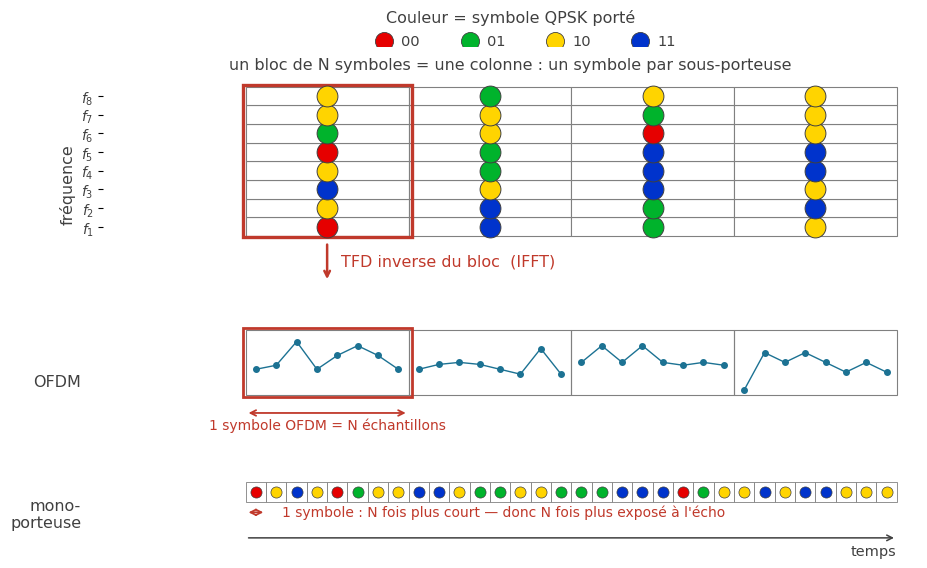

Les trois bandes partagent la MEME echelle de temps : les 4 symboles OFDM et les
32 symboles mono-porteuse transportent la meme information, dans la meme duree.
Le multi-porteuses n'a pas ralenti la transmission : il a rendu chaque symbole N fois
plus long, en en envoyant N a la fois.

POUR CODER ofdm_mod : le panneau OFDM ci-dessus est la TFD INVERSE du bloc de
symboles, ecrite ici terme a terme dans le code de la cellule. L'IFFT calcule
exactement la meme transformee, en N.log(N) operations au lieu de N^2 : c'est
tout ce qui les separe. Reste la normalisation, que VT1 tranchera.


In [7]:
# MAILLONS 2, 3 ET 4 : decoupage en blocs -> une sous-porteuse par symbole -> le signal.
# Schema volontairement reduit a N = 8 sous-porteuses : a 64, les couleurs seraient illisibles.
_Nf, _Bl = 8, 4
_X0, _X1 = -7.0, _Bl*_Nf + 1.0                     # MEME echelle de temps pour les 3 bandes
_bi = bits_alea(np.random.default_rng(11), _Bl, _Nf)
_Cg = couleur(_bi); _Xg = qam_mod(_bi)
_fig = plt.figure(figsize=(10.5, 7.0))
_gs = _fig.add_gridspec(4, 1, height_ratios=[.42, 3.0, 1.7, 1.15], hspace=.28)

_a = _fig.add_subplot(_gs[0]); _a.axis("off"); _a.set_xlim(0,1); _a.set_ylim(0,1)
_a.text(.5, .80, f"Couleur = symbole {NOM_CONST} porté" if NBITS == 2 else
        f"Couleur = symbole {NOM_CONST} porté : teinte = quadrant, nuance = sous-quadrant",
        ha="center", fontsize=11.5, color="#404040")
if NBITS == 2:
    for _k in range(4):
        _a.plot(.345+.105*_k, .18, "o", color=COUL4[_k], ms=13, mec="#404040", mew=.6)
        _a.text(.345+.105*_k+.021, .18, NOMS4[_k], va="center", fontsize=10.5,
                color="#404040")
else:                                    # la palette entiere, en 4 teintes x 4 nuances
    _n2 = 4 if NIV_COUL >= 2 else 1
    _x0 = .5 - .014*(4*_n2)/2
    for _q in range(4):
        for _t in range(_n2):
            _a.add_patch(plt.Rectangle((_x0 + .014*(_q*_n2+_t), .04), .0125, .28,
                                       color=_nuance(COUL4[_q], _t, _n2), lw=0))
    for _q in range(1, 4):               # un filet entre les quatre teintes
        _a.plot([_x0 + .014*_q*_n2 - .0008]*2, [.04, .32], color="white", lw=1.4)

_a = _fig.add_subplot(_gs[1])                       # la grille temps-frequence
for _b in range(_Bl):
    for _k in range(_Nf):
        _a.add_patch(plt.Rectangle((_b*_Nf, _k), _Nf, 1, fc="white", ec="#808080", lw=.8))
        _a.plot(_b*_Nf+_Nf/2, _k+.5, "o", color=_Cg[_b,_k], ms=15, mec="#404040", mew=.7)
_a.add_patch(plt.Rectangle((-.15,-.06), _Nf+.3, _Nf+.12, fill=False, ec="#c0392b", lw=2.4))
_a.set_xlim(_X0,_X1); _a.set_ylim(-2.9,_Nf+.5)
_a.set_yticks(np.arange(_Nf)+.5)
_a.set_yticklabels([f"$f_{{{_k+1}}}$" for _k in range(_Nf)], fontsize=10, color="#404040")
_a.set_xticks([]); _a.set_ylabel("fréquence", fontsize=11.5, color="#404040")
for _sp in _a.spines.values(): _sp.set_visible(False)
_a.set_title("un bloc de N symboles = une colonne : un symbole par sous-porteuse",
             fontsize=11.5, color="#404040")
_a.annotate("", xy=(_Nf/2,-2.45), xytext=(_Nf/2,-.3),
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.8))
_a.text(_Nf/2+.7, -1.35, "TFD inverse du bloc  (IFFT)", fontsize=11.5,
        color="#c0392b", va="center")

_a = _fig.add_subplot(_gs[2])                       # le signal = TFD inverse du bloc
_xs = []
for _b in range(_Bl):
    _xt = np.zeros(_Nf, complex)
    for _k in range(_Nf):                           # TFD inverse, ecrite terme a terme
        _xt = _xt + _Xg[_b,_k]*np.exp(2j*np.pi*_k*np.arange(_Nf)/_Nf)
    _xs.append(_xt.real)
_hb = 1.18*max(np.abs(_x).max() for _x in _xs)
for _b, _x in enumerate(_xs):
    _a.add_patch(plt.Rectangle((_b*_Nf, -_hb), _Nf, 2*_hb, fc="none", ec="#808080", lw=.8))
    _a.plot(_b*_Nf+np.arange(_Nf)+.5, _x, "o-", color="#1c7293", ms=4, lw=1.0)
_a.add_patch(plt.Rectangle((-.15,-_hb*1.05), _Nf+.3, 2.1*_hb, fill=False, ec="#c0392b", lw=2.0))
_a.annotate("", xy=(0,-_hb*1.55), xytext=(_Nf,-_hb*1.55),
            arrowprops=dict(arrowstyle="<->", color="#c0392b", lw=1.3))
_a.text(_Nf/2, -_hb*2.05, "1 symbole OFDM = N échantillons", ha="center", fontsize=10,
        color="#c0392b")
_a.set_xlim(_X0,_X1); _a.set_ylim(-_hb*2.45, _hb*1.25); _a.set_xticks([]); _a.set_yticks([])
_a.set_ylabel("OFDM", fontsize=11.5, color="#404040", rotation=0, ha="right",
              va="center", labelpad=16)
for _sp in _a.spines.values(): _sp.set_visible(False)

_a = _fig.add_subplot(_gs[3])                       # la meme information, en mono-porteuse
for _n, _c in enumerate(_Cg.reshape(-1, 3)):
    _a.add_patch(plt.Rectangle((_n, 0), 1, 1, fc="white", ec="#808080", lw=.6))
    _a.plot(_n+.5, .5, "o", color=_c, ms=8, mec="#404040", mew=.5)
_a.annotate("", xy=(0,-.5), xytext=(1,-.5),
            arrowprops=dict(arrowstyle="<->", color="#c0392b", lw=1.3))
_a.text(1.8, -.5, "1 symbole : N fois plus court — donc N fois plus exposé à l'écho",
        fontsize=10, color="#c0392b", va="center")
_a.annotate("", xy=(_Bl*_Nf,-1.75), xytext=(0,-1.75),
            arrowprops=dict(arrowstyle="->", color="#404040", lw=1.1))
_a.text(_Bl*_Nf, -2.05, "temps", ha="right", va="top", fontsize=10.5, color="#404040")
_a.set_xlim(_X0,_X1); _a.set_ylim(-2.6,1.4); _a.set_xticks([]); _a.set_yticks([])
_a.set_ylabel("mono-\nporteuse", fontsize=11.5, color="#404040", rotation=0, ha="right",
              va="center", labelpad=16)
for _sp in _a.spines.values(): _sp.set_visible(False)
plt.show()
print("Les trois bandes partagent la MEME echelle de temps : les 4 symboles OFDM et les")
print(f"{_Bl*_Nf} symboles mono-porteuse transportent la meme information, dans la meme duree.")
print("Le multi-porteuses n'a pas ralenti la transmission : il a rendu chaque symbole N fois")
print("plus long, en en envoyant N a la fois.")
print("")
print("POUR CODER ofdm_mod : le panneau OFDM ci-dessus est la TFD INVERSE du bloc de")
print("symboles, ecrite ici terme a terme dans le code de la cellule. L'IFFT calcule")
print("exactement la meme transformee, en N.log(N) operations au lieu de N^2 : c'est")
print("tout ce qui les separe. Reste la normalisation, que VT1 tranchera.")

In [8]:
def ofdm_mod(X):
    # TODO : le signal temporel est la TFD INVERSE du bloc de symboles X.
    #        La calculer par IFFT (axis=-1), puis normaliser par sqrt(N) : la convention
    #        de numpy ne conserve pas l'énergie, Parseval doit être rétabli (VT1 tranche).
    return ifft(X, axis=-1)*np.sqrt(N)   # corrigé

def ofdm_demod(y):
    # TODO : récupérer les N symboles = TFD DIRECTE du signal reçu, par FFT (axis=-1),
    #        normalisée par 1/sqrt(N) pour être l'inverse EXACT de ofdm_mod.
    return fft(y, axis=-1)/np.sqrt(N)    # corrigé

In [9]:
# --- VT1 (énergie / Parseval) : ÉCHOUE si le sqrt(N) est oublie ---
Xt = np.zeros(N, complex); Xt[5] = 1; xt = ofdm_mod(Xt)
ok1 = abs(np.sum(np.abs(xt)**2) - 1) < 1e-9
# --- VT1bis : le démodulateur doit être l'INVERSE exact du modulateur ---
Xr = qam_mod(bits_alea(np.random.default_rng(0), 3, N))
ok2 = np.allclose(ofdm_demod(ofdm_mod(Xr)), Xr, atol=1e-12)
print("VT1 OK" if ok1 else "VT1 ÉCHEC -> vérifier le sqrt(N) (énergie != 1)")
print("VT1bis OK" if ok2 else "VT1bis ÉCHEC -> mod puis demod doit redonner X exactement")

VT1 OK
VT1bis OK


**Prédire** l'allure du signal OFDM dans le temps : régulier ? périodique ? bruité ?
(cours, slide 20). Puis lancer :

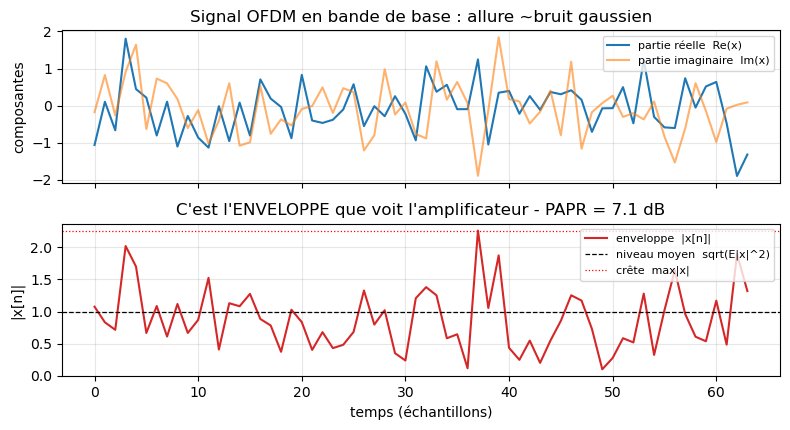

Somme de 64 sous-porteuses -> signal quasi gaussien a forts pics.
PAPR = max|x[n]|^2 / E|x[n]|^2, soit l'écart entre les deux traits du bas.
Il se calcule sur le MODULE CARRÉ : la partie réelle seule n'a pas de sens ici
(elle dépend de la phase de la porteuse, que le récepteur choisit librement).
Ces pics contraignent l'amplificateur (cours). Voir Extension E2.


In [10]:
# Allure du signal OFDM dans le temps (à prédire d'abord : régulier ? bruité ?)
# ATTENTION : le signal en bande de base est COMPLEXE. Ce qui contraint l'amplificateur,
# c'est son MODULE |x[n]| (l'enveloppe), pas sa seule partie réelle (à discuter suivant les cas !).
X1 = qam_mod(bits_alea(np.random.default_rng(0), 1, N)); x1 = ofdm_mod(X1)[0]
pmoy = np.mean(np.abs(x1)**2)                       # puissance moyenne
pmax = np.max(np.abs(x1)**2)                        # puissance de crête
papr = 10*np.log10(pmax/pmoy)                       # PAPR = crête / moyenne, sur le MODULE CARRÉ
fig, ax = plt.subplots(2,1, figsize=(8,4.4), sharex=True)
ax[0].plot(x1.real, label="partie réelle  Re(x)")
ax[0].plot(x1.imag, alpha=.6, label="partie imaginaire  Im(x)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3); ax[0].set_ylabel("composantes")
ax[0].set_title("Signal OFDM en bande de base : allure ~bruit gaussien")
ax[1].plot(np.abs(x1), "C3", label="enveloppe  |x[n]|")
ax[1].axhline(np.sqrt(pmoy), color="k", ls="--", lw=.9, label="niveau moyen  sqrt(E|x|^2)")
ax[1].axhline(np.sqrt(pmax), color="r", ls=":", lw=.9, label="crête  max|x|")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3); ax[1].set_ylabel("|x[n]|")
ax[1].set_xlabel("temps (échantillons)")
ax[1].set_title(f"C'est l'ENVELOPPE que voit l'amplificateur - PAPR = {papr:.1f} dB")
plt.tight_layout(); plt.show()
print(f"Somme de {N} sous-porteuses -> signal quasi gaussien a forts pics.")
print("PAPR = max|x[n]|^2 / E|x[n]|^2, soit l'écart entre les deux traits du bas.")
print("Il se calcule sur le MODULE CARRÉ : la partie réelle seule n'a pas de sens ici")
print("(elle dépend de la phase de la porteuse, que le récepteur choisit librement).")
print("Ces pics contraignent l'amplificateur (cours). Voir Extension E2.")

**CR 3.** A quoi sert la normalisation `1/sqrt(N)` ? Que se passe-t-il si on l'oublie (voir VT1) ?

In [11]:
# réponse : La normalisation sert à normaliser les parties émettrices / réceptrices, et donc a conserver la même puissance moyenne
# Sinon nous allons obtenir un signal avec des amplituds différentes par rapport à son envoi ce qui n'est pas notre objectif


## 4 - L'orthogonalité, visualisée (point d'orgue)
Les sous-porteuses **se recouvrent** en fréquence - et pourtant la FFT les **sépare
exactement**. C'est le point le moins intuitif du cours (slide 16). On va le voir
deux fois : en **image**, puis en **chiffre**.

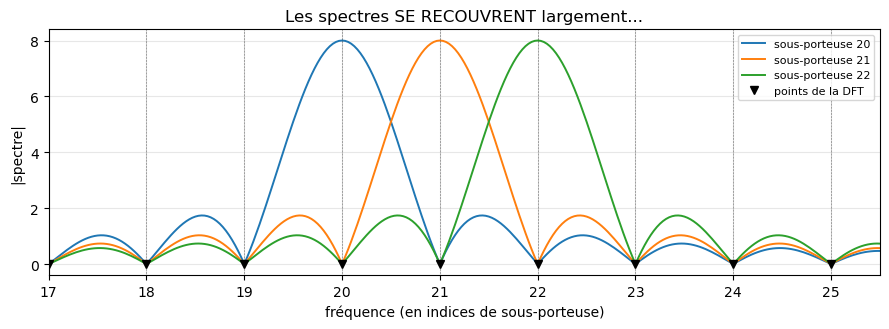

... MAIS il faut regarder les traits pointillés : au point de la DFT ou une
sous-porteuse est maximale, TOUTES les autres sont exactement nulles : c'est
précisément là que la FFT échantillonne.
Recouvrement en énergie, mais interférence nulle aux points de mesure : c'est l'ORTHOGONALITÉ.


In [12]:
# POURQUOI ça marche : le spectre de trois sous-porteuses voisines, en continu.
nz = 32                                   # sur-échantillonnage fréquentiel (pour voir le CONTINU)
f  = np.arange(N*nz)/nz                   # axe gradué en "indice de sous-porteuse"
plt.figure(figsize=(9,3.4))
for k, coul in zip([20,21,22], ["C0","C1","C2"]):
    xk = np.exp(2j*np.pi*k*np.arange(N)/N)/np.sqrt(N)      # la sous-porteuse k, seule
    plt.plot(f, np.abs(fft(xk, N*nz)), coul, lw=1.4, label=f"sous-porteuse {k}")
for k in range(17, 26):                   # les points de la DFT = où l'on échantillonne
    plt.axvline(k, color="k", lw=.4, ls=":")
plt.plot(range(17,26), [0]*9, "kv", ms=6, label="points de la DFT")
plt.xlim(17,25.5); plt.xlabel("fréquence (en indices de sous-porteuse)"); plt.ylabel("|spectre|")
plt.title("Les spectres SE RECOUVRENT largement..."); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("... MAIS il faut regarder les traits pointillés : au point de la DFT ou une")
print("sous-porteuse est maximale, TOUTES les autres sont exactement nulles : c'est")
print("précisément là que la FFT échantillonne.")
print("Recouvrement en énergie, mais interférence nulle aux points de mesure : c'est l'ORTHOGONALITÉ.")

In [13]:
# --- VT2 (orthogonalité, en chiffre) : 3 symboles injectés sur les sous-porteuses 20,21,22 SEULEMENT ---
Xo = np.zeros((1,N), complex)
Xo[0,[20,21,22]] = qam_mod(bits_alea(np.random.default_rng(2), 3))
Xh = ofdm_demod(ofdm_mod(Xo))
attendu = np.sum(np.abs(Xo)**2)
fuite = np.sum(np.abs(np.delete(Xh[0],[20,21,22]))**2)
print(f"Énergie récupérée sur 20,21,22 : {np.sum(np.abs(Xh[0,[20,21,22]])**2):.6f} "
      f"(attendu {attendu:.3f})")
print(f"Énergie qui a FUI ailleurs     : {fuite:.1e}  (attendu ~0)")
print("VT2 OK" if fuite < 1e-20 else "VT2 ÉCHEC -> revoir ofdm_mod / ofdm_demod")

Énergie récupérée sur 20,21,22 : 3.000000 (attendu 3.000)
Énergie qui a FUI ailleurs     : 5.8e-32  (attendu ~0)
VT2 OK


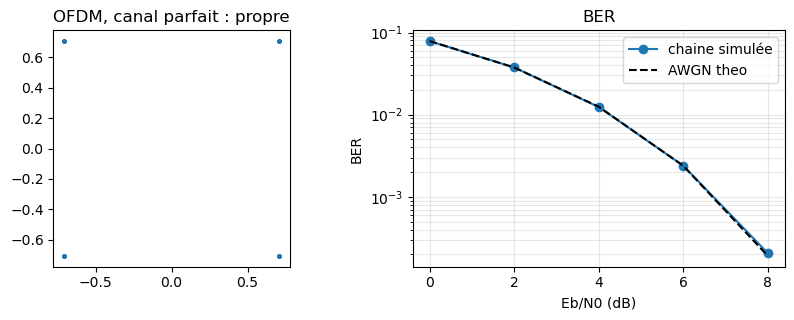

VT3 OK - la chaine est calibrée


In [14]:
# --- VT3 : la chaine en canal PARFAIT doit coller à la référence AWGN théorique ---
def _flat(eb, ns, rng):
    b = bits_alea(rng, ns, N); Xu = qam_mod(b); tx = ofdm_mod(Xu)
    N0 = 1/(10**(eb/10)*NBITS)
    y = tx + np.sqrt(N0/2)*(rng.standard_normal(tx.shape)+1j*rng.standard_normal(tx.shape))
    Z = ofdm_demod(y); return ber_of(b, Z), Z
ebs = np.arange(0,9,2); berp = [_flat(e,20000,np.random.default_rng(e))[0] for e in ebs]
th = ber_awgn(ebs); _, Zc = _flat(100,300,np.random.default_rng(1))
fig,ax = plt.subplots(1,2, figsize=(8.5,3.3))
ax[0].scatter(Zc.reshape(-1).real, Zc.reshape(-1).imag, s=3, alpha=.3); ax[0].set_aspect("equal")
ax[0].set_title("OFDM, canal parfait : propre")
ax[1].semilogy(ebs,berp,"o-",label="chaine simulée"); ax[1].semilogy(ebs,th,"k--",label="AWGN theo")
ax[1].legend(); ax[1].grid(alpha=.3,which="both"); ax[1].set_xlabel("Eb/N0 (dB)")
ax[1].set_ylabel("BER"); ax[1].set_title("BER")
plt.tight_layout(); plt.show()
print("VT3 OK - la chaine est calibrée" if abs(berp[1]/th[1]-1)<0.2
      else "VT3 ÉCHEC -> la chaine ne colle pas à la théorie, revoir les normalisations")

**CR 4.** Recouvrement **et** séparation coexistent : expliquer en une phrase comment,
en s'appuyant sur la figure (noter *où* chaque sous-porteuse s'annule).

In [15]:
# réponse : l'orthogonalité permet de mettre en évidence que chaque sous porteuse s'annule au maximum des autres.
# Eb/N0 = rapport Signal/Bruit

## 5 - MAIS : l'égalisation ne suffit pas
On passe enfin sur le **canal sélectif attribué**. Le cours (relation 4) affirme qu'une simple
division par sous-porteuse suffit à inverser le canal : `X_hat = Y / H`. On va lui donner
toutes ses chances : H sera **connu exactement** (pas d'estimation).

**À compléter :** `eq_1tap`.

In [16]:
def eq_1tap(Y, Hf):
    # TODO : égalisation "1 coefficient par sous-porteuse" (zero-forcing) : X_hat = Y / H.
    return Y/Hf   # corrigé (Hf de forme (N,) : la diffusion numpy s'applique ligne par ligne)

In [17]:
# --- VT4 : si H est connu, l'égaliseur doit rendre X exactement (sur symboles propres) ---
Xq = qam_mod(bits_alea(np.random.default_rng(0), 4, N))
print("VT4 OK" if np.allclose(eq_1tap(Xq*H_moi[None,:], H_moi), Xq, atol=1e-12) else "VT4 ÉCHEC")

VT4 OK


In [18]:
def chaine(h, eb, ns, rng):   # fourni : la chaine OFDM complete, bout a bout
    bits = bits_alea(rng, ns, N); Xu = qam_mod(bits)
    tx = ofdm_mod(Xu).reshape(-1)                          # emission
    y = np.convolve(tx, h)[:len(tx)]; N0 = 1/(10**(eb/10)*NBITS)
    y = y + np.sqrt(N0/2)*(rng.standard_normal(len(y)) + 1j*rng.standard_normal(len(y)))
    y = y.reshape(ns, N)                                   # reception
    return Xu, eq_1tap(ofdm_demod(y), fft(h,N)), bits

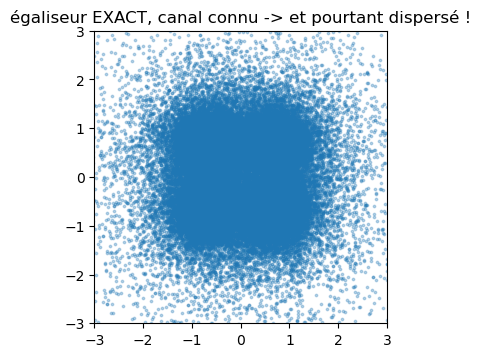

BER = 0.040  alors qu'il n'y a PRESQUE PAS DE BRUIT.
L'égaliseur est pourtant exact, et H parfaitement connu.
>>> Pourquoi la constellation reste-t-elle sale ? C'est le sujet entier du TP 2.


In [19]:
# Canal SÉLECTIF, égaliseur EXACT (H parfaitement connu), et sans bruit ou presque
# (Eb/N0 = 100 dB). Tout devrait donc être parfait.
Xu0, Xh0, b0 = chaine(h_moi, 100, 2000, np.random.default_rng(3)); z = Xh0.reshape(-1)
plt.figure(figsize=(3.8,3.8)); plt.scatter(z.real, z.imag, s=3, alpha=.3)
plt.xlim(-3,3); plt.ylim(-3,3); plt.gca().set_aspect("equal")
plt.title("égaliseur EXACT, canal connu -> et pourtant dispersé !"); plt.show()
print(f"BER = {ber_of(b0, Xh0):.3f}  alors qu'il n'y a PRESQUE PAS DE BRUIT.")
print("L'égaliseur est pourtant exact, et H parfaitement connu.")
print(">>> Pourquoi la constellation reste-t-elle sale ? C'est le sujet entier du TP 2.")

In [20]:
HYPOTHESE = "Cet égaliseur exact ne suffit pas probablement car il y a des interférences entre les symboles OFDM ?"   # pourquoi cet égaliseur EXACT ne suffit-il pas ? (tranché au TP 2)

## Extensions - pour aller plus loin (en cas d'avance)
**Non exigibles.** Chacune est indépendante et se lance seule. Consigner les observations.

### E1 - changer de constellation (16-QAM, 64-QAM)

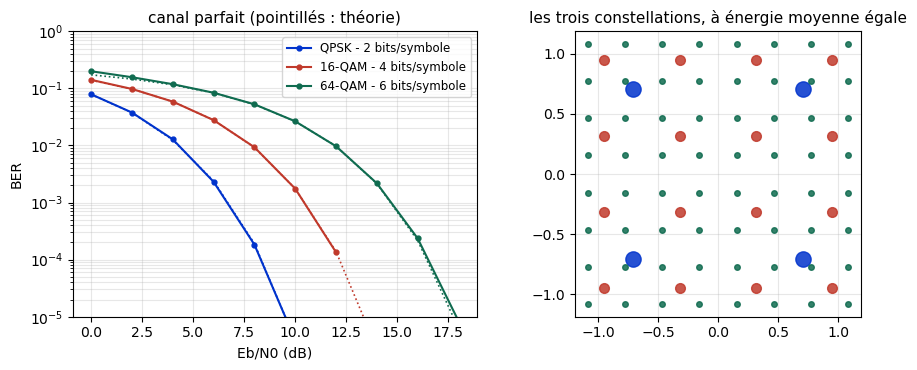

A BANDE EGALE, 16-QAM double le debit de la QPSK, et 64-QAM le triple.
En echange, a energie moyenne egale les points sont plus rapproches. Pour tenir
BER = 1e-4, il faut 8.4 dB en QPSK, 12.2 dB en 16-QAM, 16.5 dB en 64-QAM :
environ 4 dB a chaque doublement du debit. C'est l'arbitrage debit / robustesse,
celui que l'ADSL regle sous-porteuse par sous-porteuse.
NBITS est revenu a 2 : la suite du notebook reste en QPSK.


In [21]:
# E1 - changer de constellation : TOUTE la chaine suit NBITS, y compris les fonctions
# deja ecrites. On rejoue donc la meme chaine, en canal PARFAIT, pour trois tailles.
def _chaine_plate(m, eb, ns, rng):
    global NBITS
    NBITS = m                                   # tout le reste du code s'y conforme
    b  = bits_alea(rng, ns, N); tx = ofdm_mod(qam_mod(b))
    N0 = 1/(10**(eb/10)*m)
    y  = tx + np.sqrt(N0/2)*(rng.standard_normal(tx.shape)+1j*rng.standard_normal(tx.shape))
    return ber_of(b, ofdm_demod(y), m)

_sauve = NBITS
_ebs = np.arange(0, 19, 2)
_cas = [(2,"#0033cc","QPSK"), (4,"#c0392b","16-QAM"), (6,"#0f6b4f","64-QAM")]
_res = []                                       # tout mesurer AVANT de tracer quoi que ce soit
for _m, _c, _nom in _cas:
    _mes = np.array([_chaine_plate(_m, _e, 4000, np.random.default_rng(100+_e)) for _e in _ebs])
    _res.append((_mes, qam_mod(mots_binaires(_m), _m)))
NBITS = _sauve                                  # on remet la constellation du TP
_fig, _ax = plt.subplots(1, 2, figsize=(9.4, 3.8))
for (_m, _c, _nom), (_mes, _pts) in zip(_cas, _res):
    _ax[0].semilogy(_ebs, np.where(_mes > 0, _mes, np.nan), "o-", color=_c, ms=3.5,
                    label=f"{_nom} - {_m} bits/symbole")
    _ax[0].semilogy(_ebs, ber_awgn(_ebs, _m), ":", color=_c, lw=1.2)
    _ax[1].plot(_pts.real, _pts.imag, "o", color=_c, ms=[0,0,11,0,7,0,4][_m], alpha=.85)
_ax[0].set_ylim(1e-5, 1); _ax[0].grid(alpha=.3, which="both"); _ax[0].legend(fontsize=8.5)
_ax[0].set_xlabel("Eb/N0 (dB)"); _ax[0].set_ylabel("BER")
_ax[0].set_title("canal parfait (pointillés : théorie)", fontsize=11)
_ax[1].set_aspect("equal"); _ax[1].grid(alpha=.3)
_ax[1].set_title("les trois constellations, à énergie moyenne égale", fontsize=11)
plt.tight_layout(); plt.show()
print("A BANDE EGALE, 16-QAM double le debit de la QPSK, et 64-QAM le triple.")
print("En echange, a energie moyenne egale les points sont plus rapproches. Pour tenir")
print("BER = 1e-4, il faut 8.4 dB en QPSK, 12.2 dB en 16-QAM, 16.5 dB en 64-QAM :")
print("environ 4 dB a chaque doublement du debit. C'est l'arbitrage debit / robustesse,")
print("celui que l'ADSL regle sous-porteuse par sous-porteuse.")
print(f"NBITS est revenu a {NBITS} : la suite du notebook reste en {NOM_CONST}.")

### E2 - PAPR (les pics du signal OFDM)

**Définition.** PAPR = puissance de crête / puissance moyenne, calculée sur le **module
carré** de l'enveloppe complexe :  `PAPR = max|x[n]|^2 / E{|x[n]|^2}`.
Deux pièges classiques, que cette extension met en évidence :
1. le calculer sur `Re(x)` seul (sans le module) - c'est faux ;
2. le calculer sur les seuls N échantillons du symbole - c'est **sous-estimé**, car les
   vrais pics tombent souvent *entre* deux échantillons.

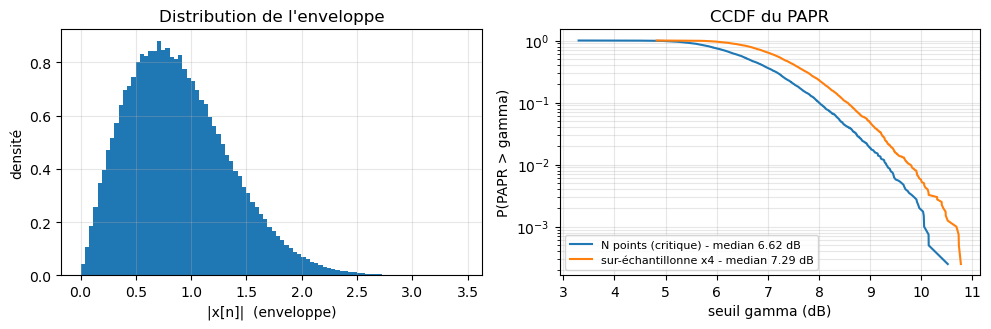

PAPR median, N points (critique) :  6.62 dB
   théorie (enveloppe gaussienne, médiane) :  6.56 dB  -> chaine conforme
PAPR median, sur-échantillonne x4       :  7.29 dB  <-- la VRAIE valeur
   (+0.7 dB : les pics entre échantillons, invisibles à la cadence critique)
A comparer au chiffre du cours (slide 32, ~7 dB à N=64).

CONVENTION - à préciser toujours, sous peine de 3 dB d'écart :
  * ici, PAPR de l'ENVELOPPE COMPLEXE en bande de base : max|x|^2 / E|x|^2.
  * le signal RF réel s(t) = Re{x(t).e^{j.2.pi.fc.t}} a un PAPR supérieur de 3 dB
    exactement (sa puissance moyenne vaut E|x|^2/2, sa crête reste max|x|).
  * la littérature OFDM emploie majoritairement la convention bande de base.


In [22]:
# E2 - PAPR : distribution, effet du sur-échantillonnage, et les deux conventions.
def papr_db(sig):   # PAPR par symbole, en dB, sur le MODULE CARRÉ
    return 10*np.log10(np.max(np.abs(sig)**2, axis=-1)/np.mean(np.abs(sig)**2, axis=-1))

ns = 4000
Xm = qam_mod(bits_alea(np.random.default_rng(3), ns, N))
xm = ofdm_mod(Xm)                                     # échantillonnage critique (N points)
L  = 4                                                # sur-échantillonnage : pour voir ENTRE les points
Xz = np.concatenate([Xm[:,:N//2], np.zeros((ns,N*(L-1)),complex), Xm[:,N//2:]], axis=1)
xo = ifft(Xz, axis=-1)*np.sqrt(N)*L                   # même signal, mieux échantillonne

fig, ax = plt.subplots(1,2, figsize=(10,3.4))
ax[0].hist(np.abs(xo).reshape(-1), bins=90, density=True)
ax[0].set_xlabel("|x[n]|  (enveloppe)"); ax[0].set_ylabel("densité")
ax[0].set_title("Distribution de l'enveloppe"); ax[0].grid(alpha=.3)
for sig, lab in [(xm, f"N points (critique)"), (xo, f"sur-échantillonne x{L}")]:
    p = np.sort(papr_db(sig))
    ax[1].semilogy(p, 1-np.arange(p.size)/p.size, label=f"{lab} - median {np.median(p):.2f} dB")
ax[1].set_xlabel("seuil gamma (dB)"); ax[1].set_ylabel("P(PAPR > gamma)")
ax[1].set_title("CCDF du PAPR"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

th = 10*np.log10(-np.log(1-0.5**(1/N)))    # médiane théorique, |x|^2 exponentiel (N grand)
print(f"PAPR median, N points (critique) : {np.median(papr_db(xm)):5.2f} dB")
print(f"   théorie (enveloppe gaussienne, médiane) : {th:5.2f} dB  -> chaine conforme")
print(f"PAPR median, sur-échantillonne x{L}       : {np.median(papr_db(xo)):5.2f} dB  <-- la VRAIE valeur")
print(f"   (+{np.median(papr_db(xo))-np.median(papr_db(xm)):.1f} dB : les pics entre échantillons, invisibles à la cadence critique)")
print(f"A comparer au chiffre du cours (slide 32, ~7 dB à N=64).")
print("")
print("CONVENTION - à préciser toujours, sous peine de 3 dB d'écart :")
print("  * ici, PAPR de l'ENVELOPPE COMPLEXE en bande de base : max|x|^2 / E|x|^2.")
print("  * le signal RF réel s(t) = Re{x(t).e^{j.2.pi.fc.t}} a un PAPR supérieur de 3 dB")
print("    exactement (sa puissance moyenne vaut E|x|^2/2, sa crête reste max|x|).")
print("  * la littérature OFDM emploie majoritairement la convention bande de base.")

### E3 - CFO (un petit décalage de fréquence casse l'orthogonalité)

**Définition de `eps`.** Le décalage de fréquence porteuse est exprimé **normalisé par
l'espacement entre sous-porteuses** : `eps = décalage_de_porteuse / Delta_f`, avec
`Delta_f = 1/Tu = Fe/N` (cours, relation 1). C'est une grandeur **sans dimension** :
`eps = 0.10` signifie « décalage de 10 % de l'espacement ». En bande de base, cela revient
à multiplier le signal reçu par `exp(j.2.pi.eps.n/N)`, n étant l'indice d'échantillon.
C'est la convention usuelle de la littérature OFDM.

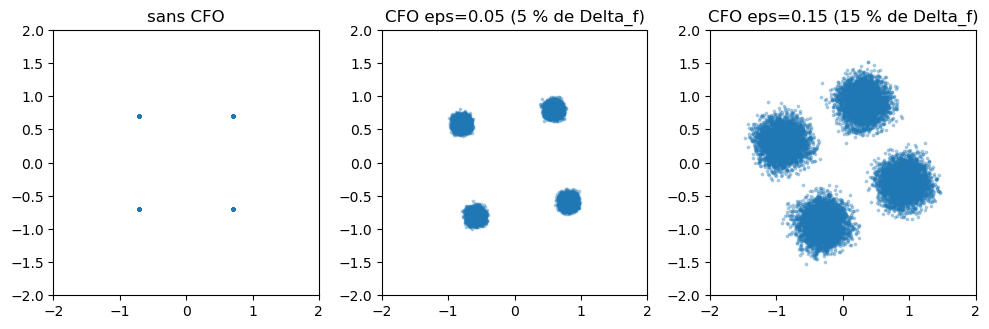

Quelques pour cent de l'espacement suffisent à faire tourner et baver la constellation :
l'énergie d'une sous-porteuse fuit sur ses voisines (ICI). D'où la resynchronisation
permanente des récepteurs réels (cours, slide 33).

Cas particulier instructif : un eps ENTIER (1, 2, ...) ne crée AUCUNE ICI - le décalage
vaut alors un nombre entier d'espacements, et l'effet se réduit à une PERMUTATION
circulaire des sous-porteuses. C'est la partie FRACTIONNAIRE de eps qui détruit
l'orthogonalité.


In [23]:
# E3 - CFO : un décalage de fréquence porteuse casse l'orthogonalité.
# eps = décalage / Delta_f, sans dimension ; en bande de base : rampe de phase exp(j.2.pi.eps.n/N).
Xc = qam_mod(bits_alea(np.random.default_rng(1), 200, N)); xc = ofdm_mod(Xc)
fig,ax = plt.subplots(1,3, figsize=(10,3.4))
for a,(eps,t) in zip(ax, [(0.0,"sans CFO"),(0.05,"CFO eps=0.05 (5 % de Delta_f)"),
                          (0.15,"CFO eps=0.15 (15 % de Delta_f)")]):
    xr = xc*np.exp(1j*2*np.pi*eps*np.arange(N)/N)[None,:]   # eps NORMALISÉ par l'espacement
    Z = ofdm_demod(xr).reshape(-1)
    a.scatter(Z.real, Z.imag, s=3, alpha=.3); a.set_aspect("equal")
    a.set_xlim(-2,2); a.set_ylim(-2,2); a.set_title(t)
plt.tight_layout(); plt.show()
print("Quelques pour cent de l'espacement suffisent à faire tourner et baver la constellation :")
print("l'énergie d'une sous-porteuse fuit sur ses voisines (ICI). D'où la resynchronisation")
print("permanente des récepteurs réels (cours, slide 33).")
print("")
print("Cas particulier instructif : un eps ENTIER (1, 2, ...) ne crée AUCUNE ICI - le décalage")
print("vaut alors un nombre entier d'espacements, et l'effet se réduit à une PERMUTATION")
print("circulaire des sous-porteuses. C'est la partie FRACTIONNAIRE de eps qui détruit")
print("l'orthogonalité.")

**CR extensions.** Une observation notable ?

In [ ]:
# notes :

---
# TP 2 - la suite : le préfixe cyclique et la performance
Le TP 1 est terminé (ci-dessus). On répond maintenant à la question laissée ouverte au
poste 5 : **pourquoi l'égaliseur exact ne suffisait pas**, et comment le **préfixe
cyclique** le répare.

## 6 - Le préfixe cyclique (la cle)
On recopie la **fin** de chaque symbole en tête (cours, slides 21-23).

Le préfixe cyclique est l'objet de cette séance : c'est donc **à écrire soi-même**. La
version fournie plus haut (pour que le poste 5 tourne) est remplacée par la vôtre.

**Prédire** ensuite la longueur minimale nécessaire, en échantillons. Indice : la seule
grandeur du problème qui a la dimension d'un retard est l'étalement des retards tau du
canal attribué.

Voici **le dernier maillon de la chaîne**, en image — à regarder **avant** d'écrire la
fonction : ce que l'insertion du préfixe cyclique fait au symbole, et ce qu'elle coûte.

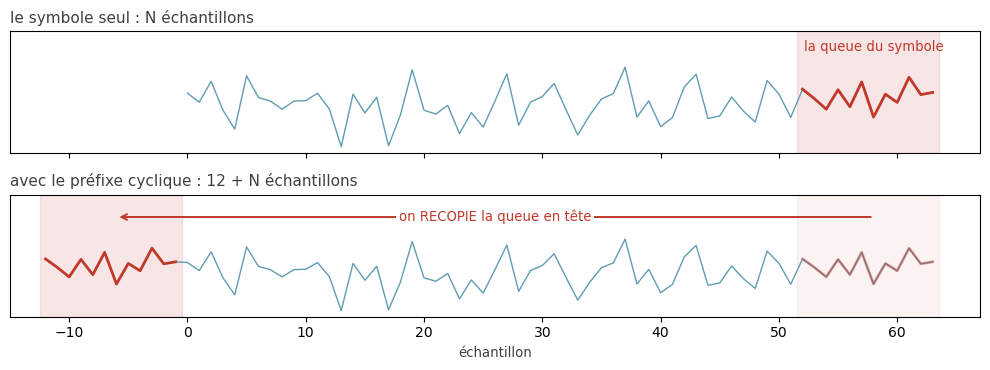

Le symbole emis durerait 12+64 = 76 echantillons au lieu de 64 :
16 % du temps d'antenne partirait dans une redite. C'est le PRIX du prefixe.
A ecrire maintenant, pour un LOT de symboles (forme (ns, N)) et pour cp = 0 aussi.


In [24]:
# LE PREFIXE CYCLIQUE, EN IMAGE - a regarder avant d'ecrire la fonction.
# (ici sur la partie reelle d'un seul symbole, en 1-D : c'est l'IDEE, pas le code demande)
_cpf = 12
_xr = np.real(ofdm_mod(qam_mod(bits_alea(np.random.default_rng(3), N))))
_ycp = np.concatenate([_xr[N-_cpf:], _xr])
_hh = np.abs(_xr).max()
_fig, _ax = plt.subplots(2, 1, figsize=(10, 3.8), sharex=True)
_a = _ax[0]
_a.plot(np.arange(N), _xr, color="#609cb3", lw=1.0)
_a.plot(np.arange(N-_cpf, N), _xr[N-_cpf:], color="#c0392b", lw=2.0)
_a.axvspan(N-_cpf-.5, N-.5, color="#c0392b", alpha=.12)
_a.text(N-_cpf/2, _hh*1.12, "la queue du symbole", ha="center", fontsize=9.5, color="#c0392b")
_a.set_ylim(-_hh*1.15, _hh*1.55); _a.set_yticks([])
_a.set_title("le symbole seul : N échantillons", fontsize=11, color="#404040", loc="left")
_a = _ax[1]
_a.plot(np.arange(-_cpf, N), _ycp, color="#609cb3", lw=1.0)
_a.plot(np.arange(-_cpf, 0), _ycp[:_cpf], color="#c0392b", lw=2.0)
_a.plot(np.arange(N-_cpf, N), _xr[N-_cpf:], color="#c0392b", lw=2.0, alpha=.45)
_a.axvspan(-_cpf-.5, -.5, color="#c0392b", alpha=.12)
_a.axvspan(N-_cpf-.5, N-.5, color="#c0392b", alpha=.06)
_a.annotate("", xy=(-_cpf/2, _hh*1.30), xytext=(N-_cpf/2, _hh*1.30),
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.4))
_a.text(N/2-_cpf/2, _hh*1.30, "on RECOPIE la queue en tête", ha="center", va="center",
        fontsize=9.5, color="#c0392b", bbox=dict(fc="white", ec="none", pad=2.0))
_a.set_ylim(-_hh*1.15, _hh*1.85); _a.set_yticks([]); _a.set_xlim(-_cpf-3, N+3)
_a.set_xlabel("échantillon", fontsize=9.5, color="#404040")
_a.set_title(f"avec le préfixe cyclique : {_cpf} + N échantillons", fontsize=11,
             color="#404040", loc="left")
plt.tight_layout(); plt.show()
print(f"Le symbole emis durerait {_cpf}+{N} = {_cpf+N} echantillons au lieu de {N} :")
print(f"{100*_cpf/(N+_cpf):.0f} % du temps d'antenne partirait dans une redite. C'est le PRIX du prefixe.")
print("A ecrire maintenant, pour un LOT de symboles (forme (ns, N)) et pour cp = 0 aussi.")

In [27]:
def ajoute_cp(x, cp):
    # TODO : recopier les cp DERNIERS echantillons de chaque symbole EN TETE de ce symbole.
    #        x a la forme (ns, N) ; le resultat a la forme (ns, N+cp).
    #        Cas cp = 0 : renvoyer x inchange.
    if cp == 0:
        return x

    # Les cp derniers échantillons sont placés en tête
    return np.concatenate((x[:, -cp:], x), axis=1)

In [28]:
# --- VT5 : le prefixe doit etre la COPIE EXACTE de la queue du symbole ---
xt = np.arange(2*N, dtype=float).reshape(2, N)
yt = ajoute_cp(xt, 4)
ok = (yt.shape == (2, N+4)) and np.allclose(yt[:, :4], xt[:, -4:]) and np.allclose(yt[:, 4:], xt)
print("VT5 OK" if ok else "VT5 ECHEC -> le prefixe doit valoir x[N-cp:], place AVANT le symbole")
print("VT5bis OK" if np.allclose(ajoute_cp(xt, 0), xt) else "VT5bis ECHEC -> cp=0 doit renvoyer x inchange")

VT5 OK
VT5bis OK


In [29]:
def chaine(h, eb, ns, cp, rng):   # fourni : la chaine du poste 5, COMPLETEE par le prefixe
    bits = bits_alea(rng, ns, N); Xu = qam_mod(bits)
    tx = ajoute_cp(ofdm_mod(Xu), cp).reshape(-1)           # <-- le seul changement
    y = np.convolve(tx, h)[:len(tx)]; N0 = 1/(10**(eb/10)*NBITS)
    y = y + np.sqrt(N0/2)*(rng.standard_normal(len(y)) + 1j*rng.standard_normal(len(y)))
    y = y.reshape(ns, N+cp)
    return Xu, eq_1tap(ofdm_demod(y[:,cp:]), fft(h,N)), bits   # le prefixe est JETE a la reception
print("chaine() accepte desormais une longueur de prefixe cp.")

chaine() accepte desormais une longueur de prefixe cp.


In [46]:
PREDICTION_CP = tau # cp >= Tau échantillons or on a tau=13 donc cp >= 13

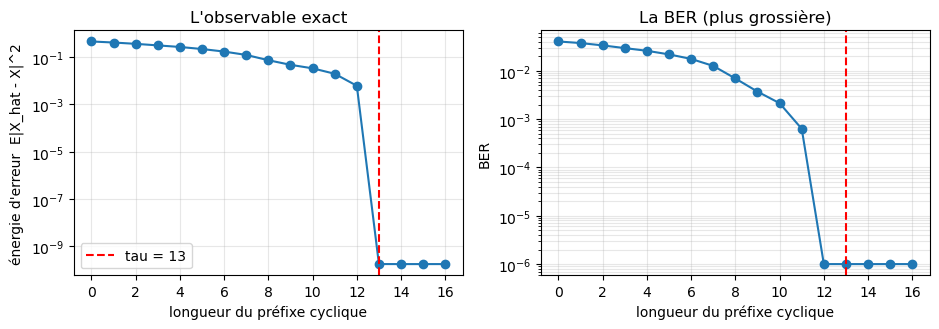

Seuil observe (énergie d'erreur) = 13   |   étalement des retards tau = 13
Prédiction consignée : 13

Note : l'énergie d'erreur chute de ~8 DÉCADES d'un seul coup - c'est un seuil FRANC.
La BER, elle, descend progressivement et atteint 0 un peu AVANT le seuil : une ISI
résiduelle faible ne fait pas encore franchir de frontière de décision. La BER est un
indicateur trop grossier pour lire ce seuil ; l'énergie d'erreur est le bon observable.


In [47]:
# Balayage de la longueur du préfixe cyclique, de 0 à tau+3, sur le canal sélectif attribué.
# On mesure DEUX choses : l'énergie d'erreur résiduelle (l'observable exact) et la BER.
cps = list(range(0, tau+4)); errs = []; bers = []
for cp in cps:
    X, Xh, b = chaine(h_moi, 100, 2000, cp, np.random.default_rng(7))
    errs.append(np.mean(np.abs(Xh-X)**2)); bers.append(ber_of(b, Xh))
fig, ax = plt.subplots(1,2, figsize=(9.5,3.4))
ax[0].semilogy(cps, errs, "o-"); ax[0].axvline(tau, color="r", ls="--", label=f"tau = {tau}")
ax[0].set_xlabel("longueur du préfixe cyclique"); ax[0].set_ylabel("énergie d'erreur  E|X_hat - X|^2")
ax[0].set_title("L'observable exact"); ax[0].legend(); ax[0].grid(alpha=.3, which="both")
ax[1].semilogy(cps, np.array(bers)+1e-6, "o-"); ax[1].axvline(tau, color="r", ls="--")
ax[1].set_xlabel("longueur du préfixe cyclique"); ax[1].set_ylabel("BER")
ax[1].set_title("La BER (plus grossière)"); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
seuil = next((cp for cp in cps if errs[cp] < 1e-6), None)
print(f"Seuil observe (énergie d'erreur) = {seuil}   |   étalement des retards tau = {tau}")
print(f"Prédiction consignée : {PREDICTION_CP}")
print("")
print("Note : l'énergie d'erreur chute de ~8 DÉCADES d'un seul coup - c'est un seuil FRANC.")
print("La BER, elle, descend progressivement et atteint 0 un peu AVANT le seuil : une ISI")
print("résiduelle faible ne fait pas encore franchir de frontière de décision. La BER est un")
print("indicateur trop grossier pour lire ce seuil ; l'énergie d'erreur est le bon observable.")

Le seuil est net. Mais il reste **la** question du cours (slide 23) : pourquoi recopier la
**queue**, plutôt que d'insérer des **zéros** ? Des zéros empêcheraient déjà le débordement
d'un bloc sur le suivant. La démonstration ci-dessous tranche, sur un exemple minuscule.

In [35]:
# Convolution LINÉAIRE vs CIRCULAIRE, sur un bloc de N=4 échantillons et un canal a 2 trajets.
xb = np.array([1., 2., 3., 4.]); hb = np.array([1., 0.5])       # bloc et canal jouets
lin  = np.convolve(xb, hb)[:4]                                   # ce que fait le canal, brut
circ = np.real(ifft(fft(xb)*fft(hb, 4)))                         # ce que la DFT diagonalise
zp   = np.convolve(np.concatenate([[0.], xb]), hb)[1:5]          # avec un préfixe de ZÉROS
cp   = np.convolve(np.concatenate([xb[-1:], xb]), hb)[1:5]       # avec le PRÉFIXE CYCLIQUE
print(f"bloc x           = {xb}      canal h = {hb}")
print(f"conv. LINÉAIRE   = {lin}   <- x[0] ne voit RIEN avant lui")
print(f"conv. CIRCULAIRE = {circ}   <- x[0] voit x[3] : le bloc 'boucle'")
print(f"préfixe de ZÉROS = {zp}   <- pas d'interférence entre blocs, mais PAS circulaire")
print(f"préfixe CYCLIQUE = {cp}   <- identique à la circulaire : GAGNE")
print("")
print("Les zéros règlent le débordement entre blocs, mais laissent la convolution LINÉAIRE.")
print("Or Y[k] = H[k].X[k] n'est vrai que pour la convolution CIRCULAIRE (théorème de la DFT).")
print("En recopiant la queue devant la tête, on fait 'voir' la fin du bloc a son début : le")
print("bloc paraît périodique, le canal boucle, et la DFT le diagonalise. C'est LA raison.")

bloc x           = [1. 2. 3. 4.]      canal h = [1.  0.5]
conv. LINÉAIRE   = [1.  2.5 4.  5.5]   <- x[0] ne voit RIEN avant lui
conv. CIRCULAIRE = [3.  2.5 4.  5.5]   <- x[0] voit x[3] : le bloc 'boucle'
préfixe de ZÉROS = [1.  2.5 4.  5.5]   <- pas d'interférence entre blocs, mais PAS circulaire
préfixe CYCLIQUE = [3.  2.5 4.  5.5]   <- identique à la circulaire : GAGNE

Les zéros règlent le débordement entre blocs, mais laissent la convolution LINÉAIRE.
Or Y[k] = H[k].X[k] n'est vrai que pour la convolution CIRCULAIRE (théorème de la DFT).
En recopiant la queue devant la tête, on fait 'voir' la fin du bloc a son début : le
bloc paraît périodique, le canal boucle, et la DFT le diagonalise. C'est LA raison.


**CR 6.** (a) Seuil observe : la prédiction etait-elle juste ?
(b) **Pourquoi une *copie* de la queue, et pas des zéros ?** S'appuyer sur la démonstration
ci-dessus. (c) Quel est le **coût** du préfixe cyclique (que transmet-on qui ne porte aucune
information nouvelle) ? L'exprimer en pourcentage pour le canal attribué.

In [48]:
# réponse :
"""
a) Le seuil observé est atteint lorsque la longueur du préfixe cyclique vérifie cp ≥ Tau. 
À partir de ce seuil, l'énergie d'erreur chute fortement, ce qui confirme que cp est assez long pour absorber l'étalement temporel du canal

b) Cp recopie les derniers échantillons du bloc au début afin de rendre le bloc périodique. 
Après la convolution avec le canal, la convolution linéaire sur la partie utile devient équivalente à une convolution circulaire.

c) Le cp ne transporte aucune information nouvelle mais il augmante le nombre d'échantillons transmis de N à N+cp
"""

"\na) Le seuil observé est atteint lorsque la longueur du préfixe cyclique vérifie cp ≥ Tau. \nÀ partir de ce seuil, l'énergie d'erreur chute fortement, ce qui confirme que cp est assez long pour absorber l'étalement temporel du canal\n\nb) Cp recopie les derniers échantillons du bloc au début afin de rendre le bloc périodique. \nAprès la convolution avec le canal, la convolution linéaire sur la partie utile devient équivalente à une convolution circulaire.\n\nc) Le cp ne transporte aucune information nouvelle mais il augmante le nombre d'échantillons transmis de N à N+cp\n"

## 7 - La courbe de BER (performance)
Préfixe suffisant, égalisation exacte : la chaine est complète. **Prédire** l'Eb/N0
nécessaire pour atteindre BER = 1e-3, puis mesurer. Indice : le pire creux de |H| du canal
attribué coûte cher
(cours, relation 4 : l'égalisation zero-forcing **amplifie le bruit** dans les creux).

In [49]:
EBN0_1e3_PREDIT = 10.5   # <-- prédiction (en dB)

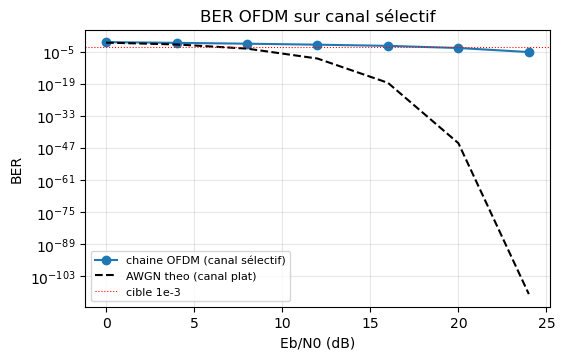

(un point à 0 est tracé à 1e-7 : la simulation manque de bits pour le mesurer)
La courbe s'écarte fortement de l'AWGN, et elle est BEAUCOUP moins pentue.
L'écart vient des CREUX de |H| : y diviser par H amplifie le bruit d'autant.


In [50]:
# Courbe de BER de la chaine OFDM complète (préfixe suffisant + égalisation zero-forcing).
ebs = np.arange(0,25,4); ber = []
for e in ebs:
    _, Xh, b = chaine(h_moi, e, 4000, tau, np.random.default_rng(e)); ber.append(ber_of(b, Xh))
th = ber_awgn(ebs)
plt.figure(figsize=(6,3.6))
plt.semilogy(ebs, np.array(ber)+1e-7, "o-", label="chaine OFDM (canal sélectif)")
plt.semilogy(ebs, th, "k--", label="AWGN theo (canal plat)")
plt.axhline(1e-3, color="r", lw=.8, ls=":", label="cible 1e-3")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER"); plt.legend(fontsize=8)
plt.grid(alpha=.3, which="both"); plt.title("BER OFDM sur canal sélectif"); plt.show()
print("(un point à 0 est tracé à 1e-7 : la simulation manque de bits pour le mesurer)")
print("La courbe s'écarte fortement de l'AWGN, et elle est BEAUCOUP moins pentue.")
print("L'écart vient des CREUX de |H| : y diviser par H amplifie le bruit d'autant.")

**CR 7.** Eb/N0 à 1e-3 : prédit vs observe. D'ou vient l'écart à l'AWGN, et pourquoi la pente
de la courbe obtenue est-elle plus faible que celle de l'AWGN ?

In [43]:
# réponse :

"""
L'écart avec l'AWGN vient du fait que le canal est sélectif en fréquence : son gain (H[k]) n'est pas le même sur toutes les sous-porteuses
La pente de la courbe BER est plus faible car toutes les sous-porteuses ne bénéficient pas du même rapport signal/bruit
"""

"\nL'écart avec l'AWGN vient du fait que le canal est sélectif en fréquence : son gain (H[k]) n'est pas le même sur toutes les sous-porteuses\nLa pente de la courbe BER est plus faible car toutes les sous-porteuses ne bénéficient pas du même rapport signal/bruit\n"

## 8 - D'ou viennent les erreurs ?
Le poste 7 a désigné un coupable : les creux. Vérifions-le directement, sous-porteuse par
sous-porteuse.

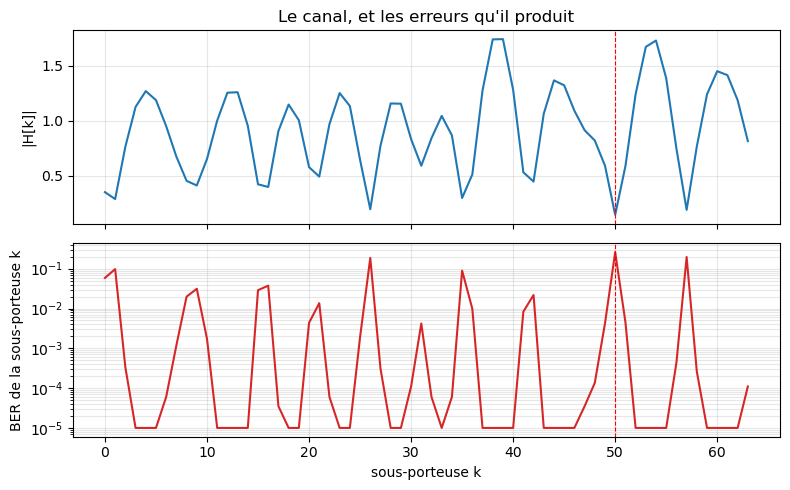

Sous-porteuse la plus faible : k = 50, |H| = 0.147
  -> sa BER = 2.59e-01   contre 3.75e-05 pour la médiane des autres.
Les erreurs ne sont PAS réparties au hasard : elles se concentrent dans les creux.


In [51]:
# Superposition de |H[k]| et de la BER PAR sous-porteuse (Eb/N0 = 10 dB).
ns = 20000
bits = bits_alea(np.random.default_rng(5), ns, N); Xu = qam_mod(bits)
tx = ajoute_cp(ofdm_mod(Xu), tau).reshape(-1)
y = np.convolve(tx, h_moi)[:len(tx)]; N0 = 1/(10**(10/10)*NBITS); rg = np.random.default_rng(6)
y = (y + np.sqrt(N0/2)*(rg.standard_normal(len(y))+1j*rg.standard_normal(len(y)))).reshape(ns,N+tau)
Xh = eq_1tap(ofdm_demod(y[:,tau:]), H_moi)
berk = np.mean(qam_demod(Xh)!=bits, axis=(0,2))
fig, ax = plt.subplots(2,1, figsize=(8,5), sharex=True)
ax[0].plot(np.abs(H_moi)); ax[0].set_ylabel("|H[k]|"); ax[0].grid(alpha=.3)
ax[0].set_title("Le canal, et les erreurs qu'il produit")
ax[1].semilogy(berk+1e-5, "C3"); ax[1].set_ylabel("BER de la sous-porteuse k")
ax[1].set_xlabel("sous-porteuse k"); ax[1].grid(alpha=.3, which="both")
kpire = int(np.argmin(np.abs(H_moi)))
for a in ax: a.axvline(kpire, color="r", ls="--", lw=.8)
plt.tight_layout(); plt.show()
print(f"Sous-porteuse la plus faible : k = {kpire}, |H| = {np.abs(H_moi[kpire]):.3f}")
print(f"  -> sa BER = {berk[kpire]:.2e}   contre {np.median(berk):.2e} pour la médiane des autres.")
print("Les erreurs ne sont PAS réparties au hasard : elles se concentrent dans les creux.")

**CR 8.** Les erreurs se concentrent-elles au hasard, ou quelque part de précis ?
Deux systèmes réels répondent différemment à ce problème : l'**ADSL** et la **TNT (DVB-T)**.
Lequel fait quoi, et **pourquoi** cette différence ? *(cours, slide 30)*

In [52]:
# réponse :
"""
La sous-porteuse ayant le plus faible (|H[k]|) présente une BER nettement supérieure à la BER médiane 
des autres sous-porteuses. Cela confirme que les erreurs sont liées à la sélectivité fréquentielle du canal.
"""

'\nLa sous-porteuse ayant le plus faible (|H[k]|) présente une BER nettement supérieure à la BER médiane \ndes autres sous-porteuses. Cela confirme que les erreurs sont directement liées à la sélectivité fréquentielle du canal.\n'

## Défi — combien de sous-porteuses peut-on garder ? *(facultatif, sans plafond)*

Le poste 8 a montré **où** sont les erreurs. On les combat maintenant, avec le seul moyen
disponible ici : **ne rien émettre** sur les sous-porteuses trop mauvaises. Une sous-porteuse
désactivée ne fait plus d'erreurs — mais elle ne transporte plus rien non plus.

> **Règle du jeu.** Eb/N0 est fixé à **12 dB**, le préfixe cyclique à tau. L'objectif est
> **BER < 10⁻³**. Le **score est le nombre de sous-porteuses laissées actives** : le plus
> élevé possible. Aucun seuil à franchir, aucune limite haute — il y a toujours mieux à faire.

Avec les 64 sous-porteuses, l'objectif n'est pas atteignable. Il faut donc en retirer, et la
question est : **lesquelles, et combien ?**

In [ ]:
def chaine_masque(h, eb, ns, cp, actives, rng):   # fourni : chaine OFDM a sous-porteuses choisies
    """Seules les sous-porteuses listees dans 'actives' portent de l'information ;
    les autres emettent zero. L'energie par bit d'information est inchangee."""
    actives = np.sort(np.unique(np.asarray(actives, dtype=int)))
    bits = bits_alea(rng, ns, len(actives))
    X = np.zeros((ns, N), complex); X[:, actives] = qam_mod(bits)
    tx = ajoute_cp(ofdm_mod(X), cp).reshape(-1)
    y = np.convolve(tx, h)[:len(tx)]; N0 = 1/(10**(eb/10)*NBITS)
    y = y + np.sqrt(N0/2)*(rng.standard_normal(len(y)) + 1j*rng.standard_normal(len(y)))
    Xh = eq_1tap(ofdm_demod(y.reshape(ns, N+cp)[:, cp:]), fft(h, N))
    return np.mean(qam_demod(Xh[:, actives]) != bits), len(actives)

# Point de depart : les 64 sous-porteuses. A modifier.
MES_ACTIVES = np.arange(N)

In [ ]:
# --- Mesure du score. Cellule a relancer apres chaque essai. ---
ber, k = chaine_masque(h_moi, 12, 8000, tau, MES_ACTIVES, np.random.default_rng(42))
debit = 100*k/N
print(f"sous-porteuses actives : {k}/{N}   ({debit:.0f} % du debit)")
print(f"BER a 12 dB            : {ber:.2e}   (objectif < 1e-3)")
if ber < 1e-3:
    print(f">>> OBJECTIF ATTEINT. SCORE = {k} sous-porteuses actives.")
    print(">>> Peut-on faire mieux ? En reactiver une, et relancer.")
else:
    print(">>> objectif non atteint : en desactiver davantage, ou mieux les choisir.")

**CR défi.** Reporter le **score** atteint et la règle utilisée pour choisir les
sous-porteuses désactivées. Puis les deux questions qui comptent :
(a) quel **pourcentage de débit** a-t-il fallu payer pour gagner ce facteur sur la BER ?
(b) un vrai système ne se contenterait pas d'éteindre ces sous-porteuses : il
**redistribuerait** la puissance ainsi libérée sur les bonnes. Comment s'appelle cette
stratégie, et lequel de l'ADSL ou de la TNT peut se le permettre ? *(cours, slides 28-30)*

In [ ]:
# réponse :

## Extension E0 - réécrire soi-même les fonctions du TP 1 *(facultatif)*
Les postes 0 à 5 ont été fournis pour que la séance tienne dans son créneau. Pour qui veut
vérifier qu'il sait les écrire seul, la cellule ci-dessous rejoue les trois trous du TP 1,
à l'aveugle. Elle ne conditionne rien du reste du notebook.

In [ ]:
# E0 - reecrire les trois fonctions du TP 1, sans regarder. Les verifications tranchent.
def mon_ofdm_mod(X):
    raise NotImplementedError("a completer")     # IFFT, normalisee pour conserver l'energie
def mon_ofdm_demod(y):
    raise NotImplementedError("a completer")     # l'inverse exact du precedent
def mon_eq_1tap(Y, Hf):
    raise NotImplementedError("a completer")     # zero-forcing, 1 coefficient par sous-porteuse

Xe = qam_mod(bits_alea(np.random.default_rng(11), 4, N))
print("E0-a", "OK" if abs(np.sum(np.abs(mon_ofdm_mod(np.eye(N)[5]))**2)-1) < 1e-9 else "A REVOIR (energie)")
print("E0-b", "OK" if np.allclose(mon_ofdm_demod(mon_ofdm_mod(Xe)), Xe, atol=1e-12) else "A REVOIR (inverse)")
print("E0-c", "OK" if np.allclose(mon_eq_1tap(Xe*H_moi[None,:], H_moi), Xe, atol=1e-12) else "A REVOIR (egaliseur)")

---
## Remise du compte-rendu (15/09/2026 minuit)

**Ce qui est rendu :** ce notebook, exécuté de bout en bout, sous le nom
`TP2_<prenom-nom>.ipnyb`.

**Avant la remise, vérifier que :**
1. `IDENTIFIANT` contient bien l'identifiant de l'auteur du compte-rendu (a défaut, le
   canal évalué n'est pas le sien) ;
2. le notebook a été relancé dans l'ordre (menu *Kernel > Restart & Run All*) et que
   **toutes les figures sont visibles** ;
3. les auto-vérifications **VT1 à VT5 affichent OK** ;
4. les cellules **CR 1 à CR 8** et les cellules de **prédiction** sont remplies -
   y compris les prédictions qui se sont révélées fausses : **on ne les efface pas**,
   une prédiction fausse assumée et analysée vaut mieux qu'une prédiction juste recopiée.

**Ce qui est évalué :** l'exactitude du code (VT), la qualité des interprétations (CR),
et l'honnêteté du raisonnement (prédictions conservées et discutées). Les Extensions ne
sont pas notées.